# CMB-HD simulation example patches
This notebook is intended to quickly generate CMB patches that are $2\degree$ by $2\degree$. While the full-sized patches in [Insert paper Link Here] are $12\degree$ by $12\degree$, we use smaller patches in this tutorial so that simulated maps and power spectra can be calculated in the notebook (there are some exceptions to this, which are pointed out). We note that the power spectra resulting from these smaller patches will vary slightly from the full-sized patches because of patch-to-patch variance.  

Full-size patches and patch power spectra are more computationally intensive and can be generated using the `.py` files referenced in this notebook.

Additionally, in this notebook, we demonstrate how to generate all CMB foregrounds, as some are treated slightly differently (diffuse vs discrete foregrounds, scaling for the tSZ and CIB, and the lack of a pixel window treatment for kappa). But we only use a single frequency (90GHz) for brevity. To use this notebook for different frequencies, just change that value.

To generate these patches, we need access to the original 2010 simulations from [https://lambda.gsfc.nasa.gov/simulation/full_sky_sims_ov.html](https://lambda.gsfc.nasa.gov/simulation/full_sky_sims_ov.html). o run this notebook, we have provided some sky patches and catalogs already in the `hdsims_output_from_example_notebook/S10_patches` and `hdsims_output_from_example_notebook/binning_files` folders, as computing them takes a long time. If you want to generate those yourself (for example, picking a different center RA, Dec), uncomment out the cells which are commented out and use `source download_90GHz_S10_data.sh` in the `S10_data/` folder to download the necessary files from the original 2010 simulations.

### Output Directories

There are three pieces to import: Foregrounds (which handles everything regarding generating the foregrounds), Spectra (which handles generating binning files and taking the power spectra for any patch of sky), and CMB (which handles generating the T,Q,U unlensed patches of sky and using the lensing convergence map for lensing).

In [1]:
from hdsims import Foregrounds, Spectra

--------------------------------------------------------------------------
detected:

  Local host:            milan1
  Device name:           mlx5_2
  Device vendor ID:      0x02c9
  Device vendor part ID: 4125

Default device parameters will be used, which may result in lower
performance.  You can edit any of the files specified by the
btl_openib_device_param_files MCA parameter to set values for your
device.

NOTE: You can turn off this warning by setting the MCA parameter
      btl_openib_warn_no_device_params_found to 0.
--------------------------------------------------------------------------
--------------------------------------------------------------------------

  Local host:   milan1
  Local device: mlx5_2
--------------------------------------------------------------------------


In [12]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import os
from matplotlib.colors import LinearSegmentedColormap
from pixell import enmap, enplot, colorize, utils, wcsutils, curvedsky as cs
from pspy import so_map, so_mcm, so_spectra
import useful_plots as upl
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.dpi'] = 250
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.xmargin'] = 0.025
plt.rcParams['axes.ymargin'] = 0.025
plt.rcParams['grid.alpha'] = 0.2
plt.rcParams['figure.figsize'] = (5, 3)
if 'planck' not in mpl.colormaps:
    colorize.mpl_setdefault('planck')

planck_cmap = plt.get_cmap('planck')
pos_cmap = upl.truncate_colormap(planck_cmap, minval=0.5, maxval=1.0, n=100)
neg_cmap = upl.truncate_colormap(planck_cmap, minval=0.0, maxval=0.5, n=100)

We also define paths to two output folders for the remainder of this notebook. In particular, results for the full-scale 144 square degree patches are in `hdsims_output/` and the results for the example 4 square degree patches are in `hdsims_output_from_example_notebook/`.

In [4]:
overall_path_full = %pwd
overall_path_full += '/hdsims_output/'
overall_path_example = %pwd
overall_path_example += '/hdsims_output_from_example_notebook/'

The full-scale 144 square degree patch results can be made by either following the python scripts (which will certainly need a supercomputer to run) or by using `source download_HD_patches.sh` in the `hdsims_output/` folder

In [5]:
S10_resolution = hp.nside2resol(8192, arcmin=True) # Original S10 0.43' pixel size
S10_resolution_kappa = hp.nside2resol(4096, arcmin=True) # Original S10 0.86' pixel size

#### Binning Files

In [ ]:
spectra_S10_kappa = Spectra(
    ra = 6,
    dec = 6,
    final_width = 2.0,
    res = S10_resolution,
    apod_width = 0.2,
    l_max = 6287)

In [ ]:
#spectra_S10.make_binning_files(binning_output_path = f"{overall_path_example}binning_files/")

In [12]:
spectra_S10_kappa = Spectra(
    ra = 6,
    dec = 6,
    final_width = 2.0,
    res = S10_resolution_kappa,
    apod_width = 0.2,
    l_max = 6287)

In [ ]:
#spectra_S10_kappa.make_binning_files(binning_output_path = f"{overall_path_example}binning_files/")

In [6]:
spectra_HD = Spectra(
    ra = 6,
    dec = 6,
    final_width = 2.0,
    res = 0.04,
    apod_width = 0.2,
    l_max = 24000)

In [ ]:
#spectra_HD.make_binning_files(binning_output_path = f"{overall_path_example}binning_files/")

In [ ]:
#spectra_HD.make_binning_files(binning_output_path = f"{overall_path_example}binning_files/", type_Cl = True)

In [ ]:
#spectra_HD.make_binning_files(binning_output_path = f"{overall_path_example}binning_files/", spin0and2 = True)

***JA: Note the BBl file for spin0and2 at 0.04 is too big to post to github ~ 414MB***

### HD Foregrounds

Note that we typically set `l_max = 24000` even though we only care up to `l_max = 20000`, as there are inaccuracies at the very end of the computation limit.

Note that, if you want to are going to run from scratch (and uncommment out the relevant parts), you'll first need to run `deconvolve_90GHz_S10_fullsky.py`, which takes the 90GHz S10 fullsky maps and deconvolves them with the pixel window (except for the lensing convergence).

#### tSZ

In [7]:
foregrounds_HD = Foregrounds(
    ra = 6,
    dec = 6,
    final_width = 2.0,
    new_res = 0.04,
    apod_width = 0.2,
    l_max = 24000)

In [9]:
#HD_tSZ_patch = foregrounds_HD.generate_diffuse_foreground(
#                component = 'tSZ',
#                frequency = 90,
#                fullsky_deconvolved_path = f"S10_data/deconvolved_fullsky/90GHz_tSZ_fullsky_deconvolved")

# This function takes in two possible sources of data, the deconvolved fullsky or a (final_width + 2*apod_width)-by-
# (final_width + 2*apod_width) patch of sky that is apodized. We provide the latter, so if you decide to uncomment out
# the section above in this cell, make sure you then comment out the section below in this cell.

HD_tSZ_patch = foregrounds_HD.generate_diffuse_foreground(
                component = 'tSZ',
                frequency = 90,
                S10_largeApodized_path = f"{overall_path_example}S10_patches/tSZ_90GHz_2.4x2.4deg_ra=6_dec=6_official")

[INFO] Upsampling to 0.04
[INFO] Convolved with pixel window
[INFO] Cut inner patch down


In [10]:
HD_tSZ_patch.write_map(f"{overall_path_example}tSZ_90Ghz_2x2deg_ra=6_dec=6")

#### kSZ

In [8]:
#S10_kSZ_patch = foregrounds_HD.generate_diffuse_foreground(
#                component = 'kSZ',
#                frequency = 90,
#                fullsky_deconvolved_path = f"S10_data/deconvolved_fullsky/90GHz_kSZ_fullsky_deconvolved")

# This function takes in two possible sources of data, the deconvolved fullsky or a (final_width + 2*apod_width)-by-
# (final_width + 2*apod_width) patch of sky that is apodized. We provide the latter, so if you decide to uncomment out
# the section above in this cell, make sure you then comment out the section below in this cell.

S10_kSZ_patch = foregrounds_HD.generate_diffuse_foreground(
                component = 'kSZ',
                frequency = 90,
                S10_largeApodized_path = f"{overall_path_example}S10_patches/kSZ_90GHz_2.4x2.4deg_ra=6_dec=6_official")

[INFO] Upsampling to 0.04
[INFO] Convolved with pixel window
[INFO] Cut inner patch down


##### Making small-scale extension theory spectra

In [9]:
ksz_template = pd.read_csv("S10_data/cmbhd_mockdata_ksz_cls_v1.1.txt", delimiter=' ')
template_ells = ksz_template['ell']
template_cls = ksz_template['C_ell^kSZ']

In [ ]:
mbb_inv, binning_file, Bbl = spectra_HD.get_binning_files(path = f"{overall_path_example}binning_files/", type_Cl = True)
S10_kSZ_cls, S10_kSZ_ells = spectra_HD.get_foreground_power(S10_kSZ_patch, mbb_inv, binning_file, deconvolve_pw = True, type_Cl = True)

[INFO] Projecting
[INFO] Deconvolving
[INFO] Get alms


In [ ]:
smallScale_kSZ_alms, smallScale_kSZ_ells, smallScale_kSZ_cls = foregrounds_HD.get_theory_for_stitching(template_cls,
                                                                          template_ells,
                                                                          S10_kSZ_cls, 
                                                                          S10_kSZ_ells, \
                                                                          template_minimization_index = 8102, 
                                                                          patch_minimization_index = 40)

##### Extending existing patch with small-scale extension

In [ ]:
kSZ_alms_for_stitching_resized = foregrounds_HD.get_S10_for_stitching(S10_kSZ_patch)

In [ ]:
HD_kSZ_patch_extended = foregrounds_HD.stitch_alms(alms_theory = smallScale_kSZ_alms, alms_S10 = kSZ_alms_for_stitching_resized, 
                                                   l_cutoff = 8000)

In [ ]:
HD_kSZ_patch_extended.write_map(f"{overall_path_example}kSZ_90Ghz_2x2deg_ra=6_dec=6")

#### Lensing Convergence (Kappa)

In [ ]:
#S10_kappa_patch = foregrounds_HD.generate_diffuse_foreground(
#                  component = 'kappa',
#                  frequency = None,
#                  fullsky_deconvolved_path = f"S10_data/deconvolved_fullsky/kappa_fullsky_deconvolved")

# This function takes in two possible sources of data, the deconvolved fullsky or a (final_width + 2*apod_width)-by-
# (final_width + 2*apod_width) patch of sky that is apodized. We provide the latter, so if you decide to uncomment out
# the section above in this cell, make sure you then comment out the section below in this cell.

S10_kappa_patch = foregrounds_HD.generate_diffuse_foreground(
                  component = 'kappa',
                  frequency = None,
                  S10_largeApodized_path = f"{overall_path_example}S10_patches/kappa_2.4x2.4deg_ra=6_dec=6_official")

##### Making small-scale extension theory spectra

In [ ]:
import camb

In [ ]:
ini_file = 'S10_data/bode_almost_wmap5_params_highKeta.ini'
pars = camb.read_ini(ini_file)

In [ ]:
# high-accuracy settings
pars.set_matter_power(kmax=10, k_per_logint=130)
pars.set_for_lmax (40000, \
    lens_potential_accuracy =30 , \
    lens_margin =2050)
pars.set_accuracy ( AccuracyBoost =1.1 , \
    lSampleBoost =3.0 , lAccuracyBoost =3.0 , \
    DoLateRadTruncation = False, min_l_logl_sampling=10000 )
pars.NonLinear = camb.model.NonLinear_both
pars.NonLinearModel.set_params("mead2016")

In [ ]:
results = camb.get_results(pars)

lensed = results.get_cmb_power_spectra(pars, CMB_unit='muK')['total']
unlensed = results.get_cmb_power_spectra(pars, raw_cl=True, CMB_unit='muK')['unlensed_scalar']

ells = np.arange(0, lensed.shape[0])
lensCL = results.get_lens_potential_cls(lmax=lensed.shape[0] + 2)
kk = (ells * (ells + 1))**2 * lensCL[2:len(ells)+2, 0] / 4.0

In [ ]:
main_data = np.column_stack([
    ells,
    lensed[:,0], lensed[:,1], lensed[:,2], lensed[:,3],
    unlensed[:,0], unlensed[:,1], unlensed[:,2], unlensed[:,3],
    kk
])

np.savetxt(
    f'{overall_path_example}camb_full_output.txt',
    main_data,
    header='ell    tt_lensed   ee_lensed   bb_lensed   te_lensed   '
           'tt_unlensed ee_unlensed bb_unlensed te_unlensed kk',
    fmt='%d %.6e %.6e %.6e %.6e %.6e %.6e %.6e %.6e %.6e'
)

In [ ]:
main_data = np.column_stack([
    ells, 
    unlensed[:,0] * (ells * (ells+1)) / (2*np.pi), 
    unlensed[:,1] * (ells * (ells+1)) / (2*np.pi), 
    unlensed[:,2] * (ells * (ells+1)) / (2*np.pi), 
    unlensed[:,3] * (ells * (ells+1)) / (2*np.pi)
])

np.savetxt(f'{overall_path_example}/camb_full_output.dat', main_data, fmt='%.6f', delimiter='\t')

Note, we save these CAMB results twice in two separate ways. The first (the .txt file) includes the lensed and unlensed output, as well as the kappa power, which is what we use for the small-scale extension. The latter (the .dat file) is useful later when it comes to generating the unlensed CMB.

In [ ]:
hddata = np.loadtxt(f"{overall_path_example}camb_full_output.txt", comments="#")
template_ells =  hddata[:,0]
template_cls = hddata[:,9]
template_cls *= 2*np.pi/(template_ells * (template_ells + 1))**2

In [ ]:
mbb_inv, binning_file, Bbl = spectra_HD.get_binning_files(path = f"{overall_path_example}binning_files/", type_Cl = True)
S10_kappa_cls, S10_kappa_ells = spectra_HD.get_foreground_power(S10_kappa_patch, mbb_inv, binning_file, deconvolve_pw = False, type_Cl = True)

In [ ]:
smallScale_kappa_alms, smallScale_kappa_ells, smallScale_kappa_cls = foregrounds_HD.get_theory_for_stitching(template_cls,
                                                                              template_ells,
                                                                              S10_kappa_cls, 
                                                                              S10_kappa_ells, \
                                                                              template_minimization_index = 3902, 
                                                                              patch_minimization_index = 19)

##### Extending existing patch with small-scale extension

In [ ]:
kappa_alms_for_stitching_resized = foregrounds_HD.get_S10_for_stitching(S10_kappa_patch)

In [ ]:
HD_kappa_patch_extended = foregrounds_HD.stitch_alms(alms_theory = smallScale_kappa_alms, alms_S10 = kappa_alms_for_stitching_resized, 
                                                   l_cutoff = 4000)

In [ ]:
HD_kappa_patch_extended.write_map(f"{overall_path_example}kappa_2x2deg_ra=6_dec=6")

#### Fig. 4 Replication

In [7]:
mbb_inv, binning_file, Bbl = spectra_HD.get_binning_files(path = f"{overall_path_example}binning_files/")

S10_kappa_dls, S10_kappa_ells = spectra_HD.get_foreground_power(S10_kappa_patch, mbb_inv, binning_file, deconvolve_pw = False)
HD_kappa_dls, HD_kappa_ells = spectra_HD.get_foreground_power(HD_kappa_patch_extended, mbb_inv, binning_file, deconvolve_pw = False)
S10_kSZ_dls, S10_kSZ_ells = spectra_HD.get_foreground_power(S10_kSZ_patch, mbb_inv, binning_file, deconvolve_pw = True)
HD_kSZ_dls, HD_kSZ_ells = spectra_HD.get_foreground_power(HD_kSZ_patch_extended, mbb_inv, binning_file, deconvolve_pw = True)

NameError: name 'S10_kappa_patch' is not defined

In [13]:
mbb_inv, binning_file, Bbl = spectra_HD.get_binning_files(path = f"{overall_path_example}binning_files/", type_Cl=True)
binned_theory_kappa_ells, binned_theory_kappa_cls = so_spectra.bin_spectra(
    smallScale_kappa_ells, smallScale_kappa_cls, binning_file, lmax=24000, type="Cl", mbb_inv=None
)
binned_theory_kSZ_ells, binned_theory_kSZ_cls = so_spectra.bin_spectra(
    smallScale_kSZ_ells, smallScale_kSZ_cls, binning_file, lmax=24000, type="Cl", mbb_inv=None
)

And below, we can plot out small-scale extended kSZ and lensing convergence (kappa) power with respect to theory. The shaded area is where the final patch of sky takes from the S10 power and the non-shaded area is where the power is from a Gaussian realization of our small-scale theory.

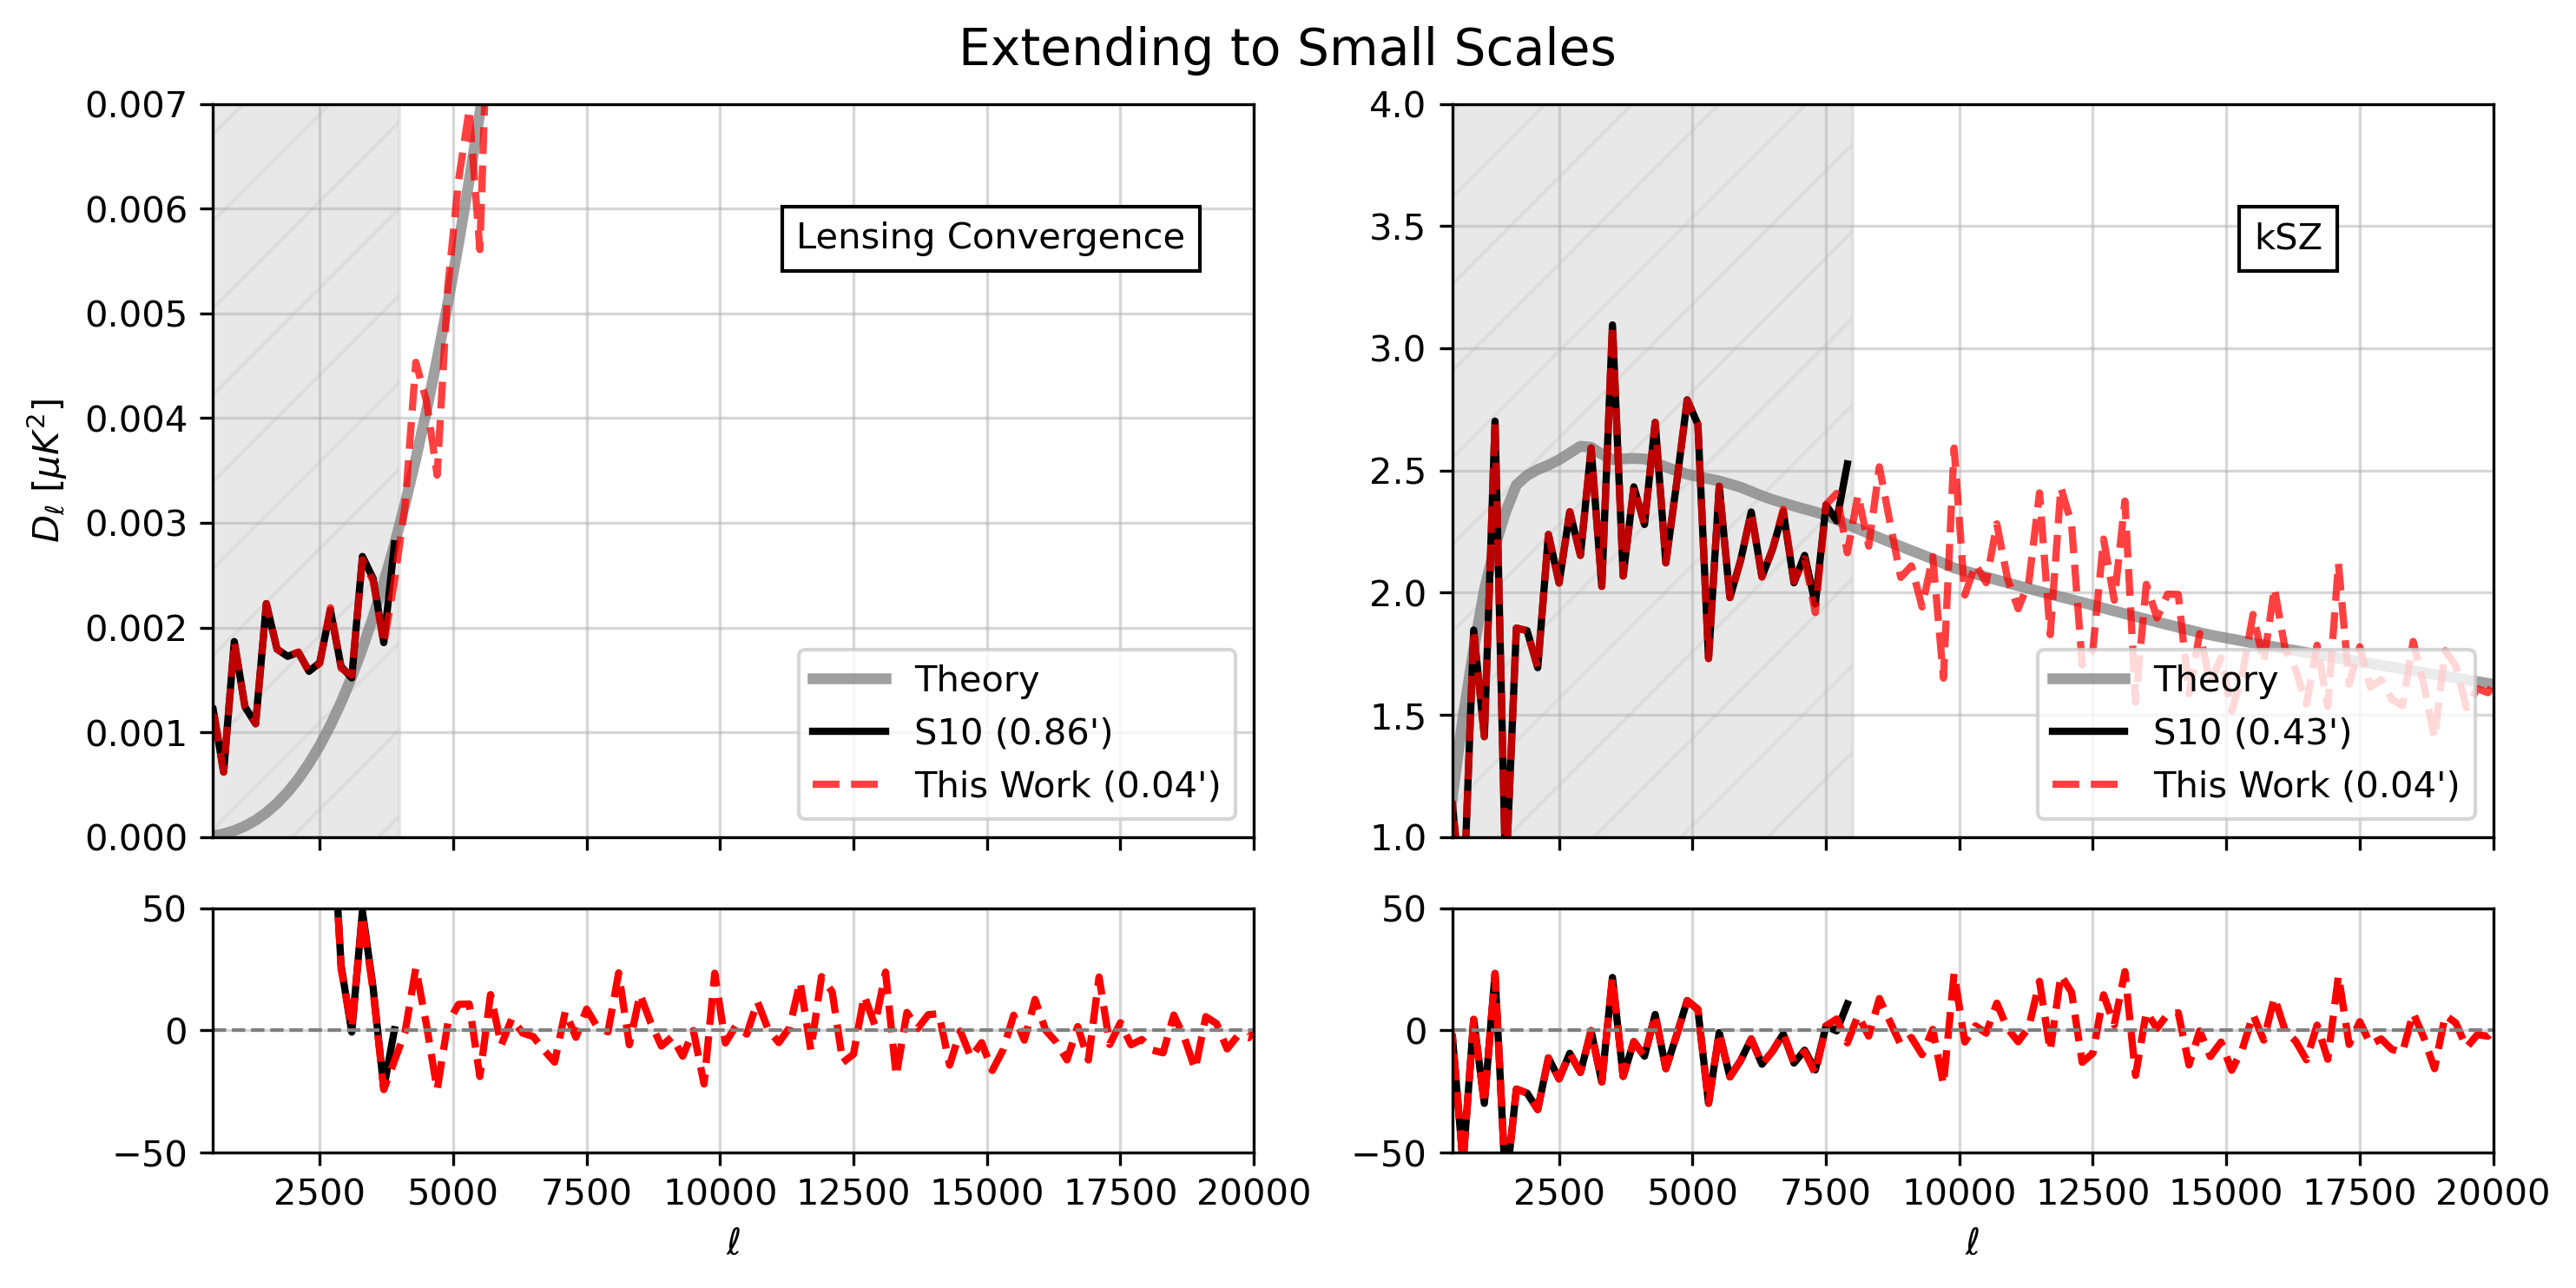

In [14]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    2, 2, figsize=(10, 5),
    gridspec_kw={'height_ratios': [3, 1]},
    sharex='col'
)
deltaEll = 200

# kappa
l_cutoff = 4000
binned_theory_kappa_dls = binned_theory_kappa_cls * (binned_theory_kappa_ells * (binned_theory_kappa_ells + 1)) / (2 * np.pi)
ax1.plot(binned_theory_kappa_ells, binned_theory_kappa_dls, color="gray", label="Theory", linewidth=3, alpha=0.75)
ax1.plot(S10_kappa_ells[:int((l_cutoff/deltaEll))], S10_kappa_dls[:int((l_cutoff/deltaEll))], color="black", label="S10 (0.86')", linewidth=2)
ax1.plot(HD_kappa_ells, HD_kappa_dls, color="red", linestyle='--', label="This Work (0.04')", linewidth=2, alpha=0.75)
ax1.axvspan(0, l_cutoff, color='lightgray', alpha=0.5, hatch='/')

ax1.text(
    x=0.02 + 0.05 - 0.65 - 0.05,
    y=3.85 - 0.15,
    s="Lensing Convergence",
    transform=plt.gca().transAxes,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle=None)
)

ax1.set_ylabel(r"$D_\ell$ [$\mu K^2$]")
ax1.set_xlim(500, 20000)
ax1.set_ylim(0, 0.007)
ax1.legend(loc='lower right')

theory_interp_S10 = np.interp(S10_kappa_ells, binned_theory_kappa_ells, binned_theory_kappa_dls)
theory_interp_HD = np.interp(HD_kappa_ells, binned_theory_kappa_ells, binned_theory_kappa_dls)
S10_percent_diff = 100 * (S10_kappa_dls - theory_interp_S10) / theory_interp_S10
HD_percent_diff = 100 * (HD_kappa_dls - theory_interp_HD) / theory_interp_HD

ax3.plot(S10_kappa_ells[:int((l_cutoff/deltaEll))], S10_percent_diff[:int((l_cutoff/deltaEll))], color='black', linewidth=2)
ax3.plot(HD_kappa_ells, HD_percent_diff, color='red', linestyle='--', linewidth=2)
ax3.axhline(0, color='gray', linestyle='--', linewidth=1)
ax3.set_xlabel(r"$\ell$")
ax3.set_ylim(-50, 50)

# ksz
l_cutoff = 8000
binned_theory_kSZ_dls = binned_theory_kSZ_cls * (binned_theory_kSZ_ells * (binned_theory_kSZ_ells + 1)) / (2 * np.pi)
ax2.plot(binned_theory_kSZ_ells, binned_theory_kSZ_dls, color="gray", label="Theory", linewidth=3, alpha=0.75)
ax2.plot(S10_kSZ_ells[:int((l_cutoff/deltaEll))], S10_kSZ_dls[:int((l_cutoff/deltaEll))], color="black", label="S10 (0.43')", linewidth=2)
ax2.plot(HD_kSZ_ells, HD_kSZ_dls, color="red", linestyle='--', label="This Work (0.04')", linewidth=2, alpha=0.75)
ax2.axvspan(0, l_cutoff, color='lightgray', alpha=0.5, hatch='/')

ax2.text(
    x=0.02 + 0.05 + 0.75 - 0.05,
    y=3.85 - 0.15,
    s="kSZ",
    transform=plt.gca().transAxes,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle=None)
)

ax2.set_xlim(500, 20000)
ax2.set_ylim(1, 4)
ax2.legend(loc='lower right')

theory_interp_S10 = np.interp(S10_kSZ_ells, binned_theory_kSZ_ells, binned_theory_kSZ_dls)
theory_interp_HD = np.interp(HD_kSZ_ells, binned_theory_kSZ_ells, binned_theory_kSZ_dls)
S10_percent_diff = 100 * (S10_kSZ_dls - theory_interp_S10) / theory_interp_S10
HD_percent_diff = 100 * (HD_kSZ_dls - theory_interp_HD) / theory_interp_HD

ax4.plot(S10_kSZ_ells[:int((l_cutoff/deltaEll))], S10_percent_diff[:int((l_cutoff/deltaEll))], color='black', linewidth=2)
ax4.plot(HD_kSZ_ells, HD_percent_diff, color='red', linestyle='--', linewidth=2)
ax4.axhline(0, color='gray', linestyle='--', linewidth=1)
ax4.set_xlabel(r"$\ell$")
ax4.set_ylim(-50, 50)

for ax in [ax1, ax2, ax3, ax4]:
    ax.grid(True, linestyle='-', alpha=0.5)

plt.tight_layout()
plt.suptitle("Extending to Small Scales", fontsize=14)
plt.subplots_adjust(top=0.92)
plt.gcf().set_dpi(300)
plt.show()

***JA: Note the kappa is off from what we want it to be. This doesn't happen for the full-scale patch and I anticipate would be resolved for deltaEll = 50. I'll change it later, but for now, let's just deal with it***

#### Radio Sources

#### CIB Model 1

#### CIB Model 2